#### ◆ Library imports


In [15]:
import re
import json
import unicodedata
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

#### ◆ Loading the datasets for analysis
- MC joint text restoration dataset
- MorisienMT
- KreolMT
- Flores-200

In [16]:
joint_text_restoration_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\data\data_versions\mc_joint_text_restoration.json"
)

morisien_mt_jsonl_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\morisien-mt-en-cr.jsonl"
)

kreol_mt_parquet_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\kreol-mt.parquet"
)

flores_jsonl_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\mfe_Latn_flores.jsonl"
)

def load_joint_text_restoration_dataset(file_path):
    """
    Load Mauritian Creole joint text restoration dataset.
    
    Format:
    JSON
    
    Returns:
        DataFrame containing the joint normalization dataset.
    """

    with open(file_path, "r", encoding="utf-8") as file:
        joint_text_restoration_data = json.load(file)

    joint_text_restoration_dataframe = pd.DataFrame(
        joint_text_restoration_data
    )

    return joint_text_restoration_dataframe

def load_kreol_mt_dataset(file_path):

    kreol_mt_data = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            kreol_mt_data.append(json.loads(line))

    kreol_mt_dataframe = pd.DataFrame(kreol_mt_data)

    kreol_mt_dataframe = kreol_mt_dataframe.rename(
        columns={
            "input": "source_text",
            "target": "target_text"
        }
    )

    return kreol_mt_dataframe

def load_morisien_mt_dataset(file_path):
    """
    Load Morisien-MT English-Creole dataset.
    
    Format:
    Parquet
    
    Returns:
        DataFrame containing Morisien-MT data.
    """

    morisien_mt_dataframe = pd.read_parquet(file_path)

    return morisien_mt_dataframe

def load_flores_dataset(file_path):
    """
    Load FLORES-200 Mauritian Creole dataset.

    Format:
        JSONL

    Returns:
        DataFrame containing the FLORES dataset.
    """

    flores_data = []

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            flores_data.append(json.loads(line))

    flores_dataframe = pd.DataFrame(flores_data)

    return flores_dataframe

mc_joint_text_restoration_df = load_joint_text_restoration_dataset(
    joint_text_restoration_dataset_path
)

morisien_mt_df = load_kreol_mt_dataset(
    morisien_mt_jsonl_dataset_path
)

kreol_mt_df = load_morisien_mt_dataset(
    kreol_mt_parquet_dataset_path
)

flores_df = load_flores_dataset(
    flores_jsonl_dataset_path
)

In [17]:
print("===== MC Joint Text Restoration Dataset =====")
display(mc_joint_text_restoration_df.head(5))

print("===== Morisien-MT Dataset =====")
display(morisien_mt_df.head(5))

kreol_mt_df = pd.json_normalize(
    kreol_mt_df["translation"]
)

display(kreol_mt_df.head(5))

print("===== FLORES Dataset =====")
display(flores_df.head(5))

===== MC Joint Text Restoration Dataset =====


,id,text,standardized
0,1,T penc nu p ekute tw😊,To pense nu pe ekut twa?😊
1,2,"[NAME], 2026 cpv encore ena dimoune sauvage co...","[NAME], 2026 kapav encore ena dimunn sauvage c..."
2,3,Les banla trace zot lavi boss... Zot ena 1 fam...,Les banla trasse zot lavi boss... Zot ena 1 fa...
3,4,Pas ti dire transport pou gratis,Pas ti dire transport pu gratis?
4,5,Eski sa mesure la li kadre avec promesse ki ti...,Eski sa mesure la li kadre avec promesse ki ti...


===== Morisien-MT Dataset =====


,source_text,target_text
0,to determine the thickness and dynamics of the...,pou determinn lepeser ek mouvman so lakok glas...
1,characterize the surface geology of Europa in ...,karakteriz zeolozi Europa en detay.
2,a science definition team NASA report has repo...,Enn lekip definision siens NASA finn raporte.
3,in a new study in the journal Astrobiology.,dan enn nouvo letid dan zournal Astrobiolozi.
4,If one day humans send a robotic lander to the...,Si enn jour imem envway enn robo lor sirfas Eu...


,src_lang,src_text,tgt_lang,tgt_text
0,mfe,administrasion.,eng,administration.
1,mfe,Tifrer sap bann granfrer.,eng,Younger brother rescues older brothers.
2,mfe,"Gardien la kontinie gout depi kalbas la, ziska...",eng,"The caretaker kept tasting from the gourd, unt..."
3,mfe,Nerolog.,eng,Neurologist.
4,mfe,Normal.,eng,Normal.


===== FLORES Dataset =====


,id,iso_639_3,iso_15924,glottocode,variant,text,url,domain,topic,has_image,has_hyperlink,last_updated,split
0,0,mfe,Latn,mori1278,,"Lindi, bann siantis depi Stanford University S...",https://en.wikinews.org/wiki/Scientists_say_ne...,wikinews,health,yes,yes,4.1,dev
1,1,mfe,Latn,mori1278,,Bann reserser prinsipal ki diriz la dir ki sa ...,https://en.wikinews.org/wiki/Scientists_say_ne...,wikinews,health,yes,yes,4.1,dev
2,2,mfe,Latn,mori1278,,JAS 39C Gripen finn kraze lor la pist apepre 9...,https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,yes,4.1,dev
3,3,mfe,Latn,mori1278,,Pilot la ti identifie kouma Squadron Leader Di...,https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,yes,4.1,dev
4,4,mfe,Latn,mori1278,,Ban media lokal finn rapporte ki ene veikil po...,https://en.wikinews.org/wiki/Fighter_jet_crash...,wikinews,accident,yes,yes,4.1,dev


#### ◆ Lexical comparison analysis

In [ ]:
# ============================================================
# LEXICAL ANALYSIS
#
# SECTION A: LEXICAL SIMILARITY
#   1. Corpus overview
#   2. Jaccard lexical similarity
#   3. Shared vocabulary
#   4. Vocabulary shared by all datasets
#   5. Facebook-only vocabulary
#
# SECTION B: LEXICAL DIVERSITY
#   6. Hapax legomena
#   7. MATTR
# ============================================================

import re
import unicodedata
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. TEXT NORMALIZATION
# ============================================================

def normalize_text(text):
    """
    Normalize text before lexical analysis.

    Operations:
    - Convert missing values to an empty string
    - Apply Unicode normalization
    - Convert text to lowercase
    - Normalize curly apostrophes
    - Remove URLs
    - Remove email addresses
    - Remove extra spaces
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Unicode-aware lowercase conversion
    text = text.casefold()

    # Normalize curly apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+\.\S+",
        " ",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


# ============================================================
# 2. TOKENIZATION
# ============================================================

def tokenize_text(text):
    """
    Extract lexical words.

    Letters are retained.

    Apostrophes and hyphens are retained only when they occur
    within words.

    Numbers, punctuation, symbols and emojis are excluded from
    this lexical analysis.
    """

    text = normalize_text(text)

    tokens = []
    current_word = []

    for index, character in enumerate(text):

        # Retain Unicode letters
        if unicodedata.category(
            character
        ).startswith("L"):

            current_word.append(
                character
            )

        # Retain apostrophes and hyphens within words
        elif (
            character in {"'", "-"}
            and current_word
            and index + 1 < len(text)
            and unicodedata.category(
                text[index + 1]
            ).startswith("L")
        ):

            current_word.append(
                character
            )

        else:

            if current_word:

                token = "".join(
                    current_word
                ).strip("'-")

                if token:
                    tokens.append(token)

                current_word = []

    # Add the final word
    if current_word:

        token = "".join(
            current_word
        ).strip("'-")

        if token:
            tokens.append(token)

    return tokens


# ============================================================
# 3. PREPARE ONE CORPUS
# ============================================================

def prepare_corpus(
    dataframe,
    text_column,
    corpus_name
):
    """
    Prepare one corpus for lexical analysis.

    Returns:
    - Dataset name
    - Number of rows
    - Original texts
    - Tokenized records
    - Flattened token list
    - Token-frequency Counter
    - Vocabulary set
    """

    if text_column not in dataframe.columns:

        raise KeyError(
            f"Column '{text_column}' was not found "
            f"in {corpus_name}.\n"
            f"Available columns: "
            f"{dataframe.columns.tolist()}"
        )

    texts = (
        dataframe[text_column]
        .fillna("")
        .astype(str)
        .tolist()
    )

    tokenized_records = [
        tokenize_text(text)
        for text in texts
    ]

    tokens = [
        token
        for record_tokens in tokenized_records
        for token in record_tokens
    ]

    frequency = Counter(tokens)

    vocabulary = set(
        frequency.keys()
    )

    return {
        "name": corpus_name,
        "number_of_rows": len(dataframe),
        "texts": texts,
        "tokenized_records": tokenized_records,
        "tokens": tokens,
        "frequency": frequency,
        "vocabulary": vocabulary
    }


# ============================================================
# 4. DETECT FLORES TEXT COLUMN
# ============================================================

def detect_flores_text_column(flores_dataframe):
    """
    Detect the likely text column in the FLORES DataFrame.
    """

    possible_columns = [
        "text",
        "sentence",
        "sentence_mfe_Latn",
        "mfe_Latn",
        "target_text",
        "translation"
    ]

    for column_name in possible_columns:

        if column_name in flores_dataframe.columns:
            return column_name

    raise KeyError(
        "The FLORES text column could not be detected.\n"
        f"Available columns: "
        f"{flores_dataframe.columns.tolist()}"
    )


# ============================================================
# 5. PREPARE ALL FOUR DATASETS
# ============================================================

def prepare_all_corpora(
    mc_joint_text_restoration_df,
    morisien_mt_df,
    kreol_mt_df,
    flores_df
):
    """
    Prepare all four Mauritian Creole datasets.
    """

    flores_text_column = (
        detect_flores_text_column(
            flores_df
        )
    )

    print(
        "FLORES-200 text column selected:",
        flores_text_column
    )

    corpora = {
        "Facebook corpus": prepare_corpus(
            dataframe=mc_joint_text_restoration_df,
            text_column="text",
            corpus_name="Facebook corpus"
        ),

        "Morisien-MT": prepare_corpus(
            dataframe=morisien_mt_df,
            text_column="target_text",
            corpus_name="Morisien-MT"
        ),

        "Kreol-MT": prepare_corpus(
            dataframe=kreol_mt_df,
            text_column="src_text",
            corpus_name="Kreol-MT"
        ),

        "FLORES-200": prepare_corpus(
            dataframe=flores_df,
            text_column=flores_text_column,
            corpus_name="FLORES-200"
        )
    }

    return corpora


# ============================================================
# SECTION A: LEXICAL SIMILARITY
# ============================================================


# ============================================================
# 6. OUTPUT 1:
# CORPUS OVERVIEW
# ============================================================

def calculate_corpus_overview(corpora):
    """
    Create a table containing:
    - Dataset name
    - Number of rows
    - Number of tokens
    - Vocabulary size
    """

    results = []

    for corpus_name, corpus in corpora.items():

        results.append({
            "Dataset": corpus_name,
            "Number of rows":
                corpus["number_of_rows"],
            "Number of tokens":
                len(corpus["tokens"]),
            "Vocabulary size":
                len(corpus["vocabulary"])
        })

    return pd.DataFrame(results)


# ============================================================
# 7. JACCARD SIMILARITY
# ============================================================

def calculate_jaccard_similarity(
    first_vocabulary,
    second_vocabulary
):
    """
    Calculate Jaccard lexical similarity.

    Jaccard similarity =
        intersection size / union size
    """

    intersection = (
        first_vocabulary &
        second_vocabulary
    )

    union = (
        first_vocabulary |
        second_vocabulary
    )

    if not union:
        return 0.0

    return (
        len(intersection) /
        len(union)
    )


def calculate_jaccard_matrix(corpora):
    """
    Create a pairwise Jaccard similarity matrix.
    """

    corpus_names = list(
        corpora.keys()
    )

    similarity_matrix = pd.DataFrame(
        index=corpus_names,
        columns=corpus_names,
        dtype=float
    )

    for first_corpus in corpus_names:

        for second_corpus in corpus_names:

            first_vocabulary = corpora[
                first_corpus
            ]["vocabulary"]

            second_vocabulary = corpora[
                second_corpus
            ]["vocabulary"]

            similarity_matrix.loc[
                first_corpus,
                second_corpus
            ] = calculate_jaccard_similarity(
                first_vocabulary,
                second_vocabulary
            )

    return similarity_matrix


# ============================================================
# 8. OUTPUT 2:
# PROFESSIONAL JACCARD HEATMAP
# ============================================================

def plot_jaccard_heatmap(
    similarity_matrix,
    save_path=None
):
    """
    Display a professional colour-coded Jaccard heatmap.
    """

    corpus_names = (
        similarity_matrix
        .columns
        .tolist()
    )

    figure, axis = plt.subplots(
        figsize=(9, 7.5)
    )

    image = axis.imshow(
        similarity_matrix.values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    # X-axis labels
    axis.set_xticks(
        np.arange(len(corpus_names))
    )

    axis.set_xticklabels(
        corpus_names,
        rotation=30,
        ha="right",
        fontsize=11
    )

    # Y-axis labels
    axis.set_yticks(
        np.arange(len(corpus_names))
    )

    axis.set_yticklabels(
        corpus_names,
        fontsize=11
    )

    # Add minor grid lines to separate cells
    axis.set_xticks(
        np.arange(
            -0.5,
            len(corpus_names),
            1
        ),
        minor=True
    )

    axis.set_yticks(
        np.arange(
            -0.5,
            len(corpus_names),
            1
        ),
        minor=True
    )

    axis.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=2
    )

    axis.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # Add Jaccard values inside cells
    for row_index in range(
        similarity_matrix.shape[0]
    ):

        for column_index in range(
            similarity_matrix.shape[1]
        ):

            score = similarity_matrix.iloc[
                row_index,
                column_index
            ]

            text_color = (
                "white"
                if score >= 0.50
                else "#1F1F1F"
            )

            axis.text(
                column_index,
                row_index,
                f"{score:.3f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
                fontweight="bold"
            )

    # Colour bar
    colour_bar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04
    )

    colour_bar.set_label(
        "Jaccard similarity",
        fontsize=11
    )

    axis.set_title(
        "Lexical similarity among the MC datasets",
        fontsize=14,
        fontweight="bold",
        pad=18
    )

    axis.set_xlabel(
        "Dataset",
        fontsize=11,
        labelpad=10
    )

    axis.set_ylabel(
        "Dataset",
        fontsize=11,
        labelpad=10
    )

    plt.tight_layout()

    if save_path:

        plt.savefig(
            save_path,
            dpi=600,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()


# ============================================================
# 9. OUTPUT 3:
# NUMBER OF SHARED VOCABULARY ITEMS
# ============================================================

def calculate_shared_vocabulary(corpora):
    """
    Calculate vocabulary shared by each pair of datasets and
    vocabulary shared by all four datasets.

    Returns:
    - Summary DataFrame
    - Dictionary containing the actual shared words
    """

    corpus_names = list(
        corpora.keys()
    )

    summary_results = []
    detailed_results = {}

    # Pairwise shared vocabulary
    for first_name, second_name in combinations(
        corpus_names,
        2
    ):

        first_vocabulary = corpora[
            first_name
        ]["vocabulary"]

        second_vocabulary = corpora[
            second_name
        ]["vocabulary"]

        shared_words = (
            first_vocabulary &
            second_vocabulary
        )

        comparison_name = (
            f"{first_name} and {second_name}"
        )

        summary_results.append({
            "Comparison": comparison_name,
            "Shared vocabulary size":
                len(shared_words)
        })

        detailed_results[
            comparison_name
        ] = shared_words

    # Vocabulary shared by all four datasets
    shared_all_datasets = set.intersection(
        *[
            corpus["vocabulary"]
            for corpus in corpora.values()
        ]
    )

    summary_results.append({
        "Comparison": "All four datasets",
        "Shared vocabulary size":
            len(shared_all_datasets)
    })

    detailed_results[
        "All four datasets"
    ] = shared_all_datasets

    summary_dataframe = pd.DataFrame(
        summary_results
    )

    return (
        summary_dataframe,
        detailed_results
    )


# ============================================================
# 10. OUTPUT 4:
# SHARED VOCABULARY AND FREQUENCIES IN ALL DATASETS
# ============================================================

def calculate_shared_vocabulary_frequencies(
    corpora,
    top_n=20
):
    """
    Produce a list of words shared by all datasets.

    Displays:
    - Raw frequency
    - Relative frequency (%) per dataset

    Words are ranked by combined frequency.
    """

    # Find words shared by all datasets
    shared_all_datasets = set.intersection(
        *[
            corpus["vocabulary"]
            for corpus in corpora.values()
        ]
    )

    results = []

    for word in shared_all_datasets:

        row = {
            "Word": word
        }

        combined_frequency = 0

        for corpus_name, corpus in corpora.items():

            # Raw frequency
            frequency = corpus["frequency"].get(
                word,
                0
            )

            combined_frequency += frequency

            # Store raw frequency
            row[
                f"{corpus_name} frequency"
            ] = frequency

            # Calculate percentage
            percentage = (
                frequency /
                len(corpus["tokens"]) *
                100
                if len(corpus["tokens"]) > 0
                else 0
            )

            row[
                f"{corpus_name} (%)"
            ] = round(
                percentage,
                3
            )

        row[
            "Combined frequency"
        ] = combined_frequency

        results.append(row)


    dataframe = pd.DataFrame(results)


    if dataframe.empty:
        return dataframe


    # Rank by total frequency
    dataframe = (
        dataframe
        .sort_values(
            by="Combined frequency",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return dataframe

# ============================================================
# 11. OUTPUT 5:
# FACEBOOK-ONLY VOCABULARY
# ============================================================

def calculate_facebook_only_vocabulary(
    corpora,
    top_n=30
):
    """
    Identify vocabulary found in the Facebook corpus but absent
    from Morisien-MT, Kreol-MT and FLORES-200.

    The words are ranked by frequency in the Facebook corpus.
    """

    facebook_vocabulary = corpora[
        "Facebook corpus"
    ]["vocabulary"]

    facebook_frequency = corpora[
        "Facebook corpus"
    ]["frequency"]

    other_datasets_vocabulary = set()

    for corpus_name, corpus in corpora.items():

        if corpus_name != "Facebook corpus":

            other_datasets_vocabulary.update(
                corpus["vocabulary"]
            )

    facebook_only_vocabulary = (
        facebook_vocabulary -
        other_datasets_vocabulary
    )

    facebook_only_rows = [
        {
            "Word": word,
            "Facebook frequency":
                facebook_frequency[word]
        }
        for word in facebook_only_vocabulary
    ]

    facebook_only_dataframe = pd.DataFrame(
        facebook_only_rows
    )

    if facebook_only_dataframe.empty:

        summary_dataframe = pd.DataFrame([
            {
                "Facebook vocabulary size":
                    len(facebook_vocabulary),
                "Facebook-only vocabulary size":
                    0,
                "Facebook-only vocabulary percentage":
                    0.0
            }
        ])

        return (
            summary_dataframe,
            facebook_only_dataframe
        )

    facebook_only_dataframe = (
        facebook_only_dataframe
        .sort_values(
            by=[
                "Facebook frequency",
                "Word"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    facebook_only_percentage = (
        len(facebook_only_vocabulary) /
        len(facebook_vocabulary) *
        100
        if facebook_vocabulary
        else 0
    )

    summary_dataframe = pd.DataFrame([
        {
            "Facebook vocabulary size":
                len(facebook_vocabulary),
            "Facebook-only vocabulary size":
                len(facebook_only_vocabulary),
            "Facebook-only vocabulary percentage":
                facebook_only_percentage
        }
    ])

    short_list = (
        facebook_only_dataframe
        .head(top_n)
        .copy()
    )

    return (
        summary_dataframe,
        short_list
    )


# ============================================================
# SECTION B: LEXICAL DIVERSITY
# ============================================================


# ============================================================
# 5. HAPAX LEGOMENA
# ============================================================

def calculate_hapax_legomena(corpora):
    """
    Hapax legomena are words occurring exactly once in a corpus.

    Returns:
        summary DataFrame
        detailed dictionary of hapax words
    """

    summary_results = []
    detailed_results = {}

    for corpus_name, corpus in corpora.items():

        hapax_words = {
            word: frequency
            for word, frequency in corpus["frequency"].items()
            if frequency == 1
        }

        vocabulary_size = len(corpus["vocabulary"])

        hapax_percentage = (
            len(hapax_words) / vocabulary_size * 100
            if vocabulary_size > 0
            else 0
        )

        detailed_results[corpus_name] = hapax_words

        summary_results.append({
            "Corpus": corpus_name,
            "Hapax count": len(hapax_words),
            "Vocabulary size": vocabulary_size,
            "Hapax percentage": hapax_percentage
        })

    return pd.DataFrame(summary_results), detailed_results


def plot_hapax_legomena(hapax_summary_df):
    """
    Visualize hapax legomena counts.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        hapax_summary_df["Corpus"],
        hapax_summary_df["Hapax count"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    plt.title("Hapax Legomena Across the Three Corpora")
    plt.xlabel("Corpus")
    plt.ylabel("Number of words occurring once")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()



# ============================================================
# 8. MOVING-AVERAGE TYPE-TOKEN RATIO
# ============================================================

def calculate_mattr_for_tokens(tokens, window_size=500):
    """
    Calculate Moving-Average Type-Token Ratio (MATTR).

    MATTR reduces the influence of different corpus sizes.

    If the corpus contains fewer tokens than the selected
    window, the ordinary TTR is returned.
    """

    if not tokens:
        return 0

    if len(tokens) <= window_size:
        return len(set(tokens)) / len(tokens)

    window_ttr_values = []

    for start_position in range(
        0,
        len(tokens) - window_size + 1
    ):
        token_window = tokens[
            start_position:start_position + window_size
        ]

        window_ttr = (
            len(set(token_window)) / window_size
        )

        window_ttr_values.append(window_ttr)

    return (
        sum(window_ttr_values) /
        len(window_ttr_values)
    )


def calculate_mattr(corpora, window_size=500):
    """
    Calculate MATTR for all corpora.
    """

    results = []

    for corpus_name, corpus in corpora.items():

        mattr_score = calculate_mattr_for_tokens(
            corpus["tokens"],
            window_size=window_size
        )

        results.append({
            "Corpus": corpus_name,
            "Window size": window_size,
            "MATTR": mattr_score,
            "MATTR percentage": mattr_score * 100
        })

    return pd.DataFrame(results)


def plot_mattr(mattr_df):
    """
    Visualize Moving-Average Type-Token Ratio.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        mattr_df["Corpus"],
        mattr_df["MATTR percentage"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    window_size = mattr_df["Window size"].iloc[0]

    plt.title(
        f"Moving-Average Type-Token Ratio "
        f"(Window = {window_size} tokens)"
    )

    plt.xlabel("Corpus")
    plt.ylabel("MATTR (%)")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

===== PREPARING CORPORA =====
FLORES-200 text column selected: text
Corpora prepared successfully.

===== CORPUS OVERVIEW =====


,Dataset,Number of rows,Number of tokens,Vocabulary size
0,Facebook corpus,13830,239313,16102
1,Morisien-MT,21810,125556,16822
2,Kreol-MT,19149,110719,15477
3,FLORES-200,997,21034,4794


===== JACCARD LEXICAL SIMILARITY =====


,Facebook corpus,Morisien-MT,Kreol-MT,FLORES-200
Facebook corpus,1.000000,0.080893,0.081547,0.070547
Morisien-MT,0.080893,1.000000,0.896038,0.144067
Kreol-MT,0.081547,0.896038,1.000000,0.149541
FLORES-200,0.070547,0.144067,0.149541,1.000000


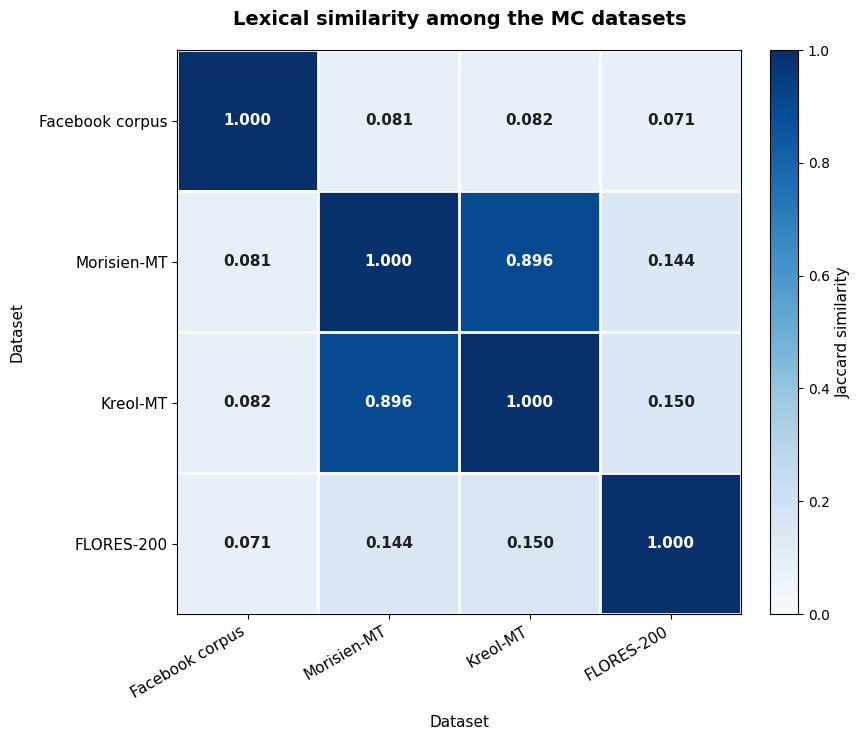

===== SHARED VOCABULARY BETWEEN DATASETS =====


,Comparison,Shared vocabulary size
0,Facebook corpus and Morisien-MT,2464
1,Facebook corpus and Kreol-MT,2381
2,Facebook corpus and FLORES-200,1377
3,Morisien-MT and Kreol-MT,15264
4,Morisien-MT and FLORES-200,2722
5,Kreol-MT and FLORES-200,2637
6,All four datasets,1011


===== TOP VOCABULARY SHARED BY ALL DATASETS =====


,Word,Facebook corpus frequency,Facebook corpus (%),Morisien-MT frequency,Morisien-MT (%),Kreol-MT frequency,Kreol-MT (%),FLORES-200 frequency,FLORES-200 (%),Combined frequency
0,la,9530,3.982,1278,1.018,1154,1.042,451,2.144,12413
1,ti,2516,1.051,5018,3.997,4399,3.973,408,1.940,12341
2,ki,4350,1.818,3610,2.875,3189,2.880,758,3.604,11907
3,li,4804,2.007,3449,2.747,3026,2.733,254,1.208,11533
4,sa,6086,2.543,1663,1.325,1493,1.348,221,1.051,9463
5,zot,4309,1.801,2201,1.753,1908,1.723,236,1.122,8654
6,pou,3832,1.601,1558,1.241,1343,1.213,460,2.187,7193
7,enn,310,0.130,3378,2.690,2961,2.674,510,2.425,7159
8,dan,1650,0.689,2335,1.860,2063,1.863,467,2.220,6515
9,ena,2495,1.043,1259,1.003,1135,1.025,186,0.884,5075


===== FACEBOOK-ONLY VOCABULARY =====


...


===== FLORES-200 =====


,Word,Frequency
0,medicine,1
1,diagnostic,1
2,re-aranz,1
3,pis,1
4,fabrike,1
5,lank,1
6,inkjet,1
7,posibman,1
8,santim,1
9,sakenn,1


===== MOVING-AVERAGE TYPE-TOKEN RATIO (MATTR) =====


,Corpus,Window size,MATTR,MATTR percentage
0,Facebook corpus,500,0.599738,59.973767
1,Morisien-MT,500,0.486553,48.655256
2,Kreol-MT,500,0.604021,60.402123
3,FLORES-200,500,0.532370,53.237010


===== LEXICAL ANALYSIS COMPLETED =====


In [24]:
# ============================================================
# MAIN EXECUTION
# ============================================================

# ============================================================
# 1. PREPARE ALL CORPORA
# ============================================================

print("===== PREPARING CORPORA =====")

corpora = prepare_all_corpora(
    mc_joint_text_restoration_df,
    morisien_mt_df,
    kreol_mt_df,
    flores_df
)

print("Corpora prepared successfully.")
print()


# ============================================================
# SECTION A: LEXICAL SIMILARITY
# ============================================================


# ============================================================
# 2. CORPUS OVERVIEW
# ============================================================

print("===== CORPUS OVERVIEW =====")

corpus_overview_df = calculate_corpus_overview(
    corpora
)

display(corpus_overview_df)

corpus_overview_df.to_csv(
    "corpus_overview.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 3. JACCARD LEXICAL SIMILARITY
# ============================================================

print("===== JACCARD LEXICAL SIMILARITY =====")

jaccard_matrix_df = calculate_jaccard_matrix(
    corpora
)

display(jaccard_matrix_df)

jaccard_matrix_df.to_csv(
    "jaccard_similarity_matrix.csv",
    encoding="utf-8-sig"
)


plot_jaccard_heatmap(
    jaccard_matrix_df,
    save_path="jaccard_similarity_heatmap.png"
)


# ============================================================
# 4. SHARED VOCABULARY
# ============================================================

print("===== SHARED VOCABULARY BETWEEN DATASETS =====")

shared_vocabulary_summary_df, shared_vocabulary_details = (
    calculate_shared_vocabulary(
        corpora
    )
)

display(shared_vocabulary_summary_df)

shared_vocabulary_summary_df.to_csv(
    "shared_vocabulary_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 5. VOCABULARY SHARED BY ALL DATASETS
# ============================================================

print("===== TOP VOCABULARY SHARED BY ALL DATASETS =====")

shared_frequency_df = calculate_shared_vocabulary_frequencies(
    corpora,
    top_n=20
)

display(shared_frequency_df)

shared_frequency_df.to_csv(
    "shared_vocabulary_frequencies.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 6. FACEBOOK-ONLY VOCABULARY
# ============================================================

print("===== FACEBOOK-ONLY VOCABULARY =====")

facebook_only_summary_df, facebook_only_words_df = (
    calculate_facebook_only_vocabulary(
        corpora,
        top_n=30
    )
)

display(facebook_only_summary_df)

display(facebook_only_words_df)

facebook_only_summary_df.to_csv(
    "facebook_only_vocabulary_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

facebook_only_words_df.to_csv(
    "facebook_only_words.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# SECTION B: LEXICAL DIVERSITY
# ============================================================


# ============================================================
# 7. HAPAX LEGOMENA
# ============================================================

print("===== HAPAX LEGOMENA =====")

hapax_summary_df, hapax_details = calculate_hapax_legomena(
    corpora
)

display(hapax_summary_df)

hapax_summary_df.to_csv(
    "hapax_legomena_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# DISPLAY SAMPLE HAPAX LEGOMENA FOR EACH DATASET
# ============================================================

print("===== SAMPLE HAPAX LEGOMENA BY DATASET =====")

for corpus_name, hapax_words in hapax_details.items():

    print()
    print(f"===== {corpus_name} =====")

    hapax_sample_df = pd.DataFrame(
        list(hapax_words.items())[:30],
        columns=[
            "Word",
            "Frequency"
        ]
    )

    display(hapax_sample_df)
    
# ============================================================
# 8. MATTR
# ============================================================

print("===== MOVING-AVERAGE TYPE-TOKEN RATIO (MATTR) =====")

mattr_df = calculate_mattr(
    corpora,
    window_size=500
)

display(mattr_df)

mattr_df.to_csv(
    "mattr_results.csv",
    index=False,
    encoding="utf-8-sig"
)


print("===== LEXICAL ANALYSIS COMPLETED =====")

#### ◆ Orthographic analysis

#### ◆◆ Diacritical analysis

In [25]:
def tokenize_for_diacritics(text):
    """
    Extract words while preserving accented characters.
    """

    if pd.isna(text):
        return []

    text = str(text).lower()

    # Keep letters including accented Unicode characters
    words = re.findall(
        r"[a-zàâçéèêëîïôûùü]+",
        text
    )

    return words


def get_diacritical_words(
    dataframe,
    text_column
):
    """
    Find words containing diacritical marks.

    Returns:
        word frequencies
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = tokenize_for_diacritics(text)

        for word in words:

            if (
                len(word) > 1
                and
                re.search(
                    r"[àâçéèêëîïôûùü]",
                    word
                )
            ):
                counter[word] += 1

    return counter


def diacritical_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Create summary statistics.
    """

    diacritical_words = get_diacritical_words(
        dataframe,
        text_column
    )

    total_words = sum(diacritical_words.values())

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Number of diacritical word types":
                len(diacritical_words),

            "Number of diacritical word occurrences":
                total_words,

            "Most frequent examples":
                ", ".join(
                    [
                        f"{word} ({count})"
                        for word, count
                        in diacritical_words.most_common(10)
                    ]
                )
        }
    ])

In [26]:
def diacritical_word_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return the most frequent words containing diacritics.
    """

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in words.most_common(top_n):

        results.append({
            "Corpus": corpus_name,
            "Word": word,
            "Frequency": frequency
        })

    return pd.DataFrame(results)

def diacritical_summary_with_counts(
    dataframe,
    text_column,
    corpus_name
):

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Diacritical word types": len(words),
            "Diacritical word occurrences": sum(words.values())
        }
    ])

In [28]:
facebook_diacritical_words = diacritical_word_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=1402
)

morisien_diacritical_words = diacritical_word_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=30
)

kreol_diacritical_words = diacritical_word_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=30
),
flores_diacritical_words = diacritical_word_table(
    flores_df,
    "text",
    "FLORES-200",
    top_n=30
)

display(facebook_diacritical_words)
display(morisien_diacritical_words)
display(kreol_diacritical_words)
display(flores_diacritical_words)

diacritical_summary = pd.concat(
    [
        diacritical_summary_with_counts(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus"
        ),

        diacritical_summary_with_counts(
            morisien_mt_df,
            "target_text",
            "Morisien-MT"
        ),

        diacritical_summary_with_counts(
            kreol_mt_df,
            "src_text",
            "Kreol-MT"
        ),
        diacritical_summary_with_counts(
            flores_df,
            "text",
            "FLORES-200"
        )
    ],
    ignore_index=True
)

display(diacritical_summary)

facebook_diacritical_words.to_csv(
    "facebook_diacritical_words.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Facebook diacritical words saved.")

,Corpus,Word,Frequency
0,Facebook corpus,même,152
1,Facebook corpus,ça,120
2,Facebook corpus,après,114
3,Facebook corpus,là,86
4,Facebook corpus,pé,58
...,...,...,...
1392,Facebook corpus,trimé,1
1393,Facebook corpus,dépasse,1
1394,Facebook corpus,loué,1
1395,Facebook corpus,prémié,1


,Corpus,Word,Frequency
0,Morisien-MT,santé,7
1,Morisien-MT,prêt,2
2,Morisien-MT,mée,2
3,Morisien-MT,émigré,1
4,Morisien-MT,passé,1
5,Morisien-MT,arête,1
6,Morisien-MT,josé,1
7,Morisien-MT,bové,1
8,Morisien-MT,bérenger,1
9,Morisien-MT,chaussée,1


(      Corpus        Word  Frequency
 0   Kreol-MT       santé          6
 1   Kreol-MT          én          2
 2   Kreol-MT         mée          2
 3   Kreol-MT      invité          1
 4   Kreol-MT  lanivérser          1
 5   Kreol-MT      émigré          1
 6   Kreol-MT   léléktora          1
 7   Kreol-MT         fér          1
 8   Kreol-MT       passé          1
 9   Kreol-MT         géj          1
 10  Kreol-MT     soufflé          1
 11  Kreol-MT    bérenger          1
 12  Kreol-MT     lorlène          1
 13  Kreol-MT        josé          1
 14  Kreol-MT        bové          1
 15  Kreol-MT        prêt          1
 16  Kreol-MT       arête          1,)

,Corpus,Word,Frequency
0,FLORES-200,zélande,4
1,FLORES-200,barça,1
2,FLORES-200,kolèg,1
3,FLORES-200,vélociraptor,1
4,FLORES-200,erkoç,1
5,FLORES-200,etmüslüm,1
6,FLORES-200,gürses,1
7,FLORES-200,âge,1
8,FLORES-200,rêve,1
9,FLORES-200,bartolomé,1


,Corpus,Diacritical word types,Diacritical word occurrences
0,Facebook corpus,1397,5737
1,Morisien-MT,12,20
2,Kreol-MT,17,24
3,FLORES-200,14,17


Facebook diacritical words saved.


#### ◆◆ Character repetition

In [29]:
def normalize_text(text):
    """
    Basic text cleaning while preserving repeated letters.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Keep letters, apostrophes and spaces
    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize(text):
    """
    Split cleaned text into words.
    """

    return normalize_text(text).split()

# ============================================================
# WORD FREQUENCIES
# ============================================================

def get_word_frequency(
    dataframe,
    text_column
):
    """
    Count the frequency of every word in a corpus.
    """

    counter = Counter()

    for text in dataframe[text_column]:
        counter.update(tokenize(text))

    return counter

# ============================================================
# DETECT CHARACTER REPETITION
# ============================================================

def has_repeated_letters(word):
    """
    Detect words containing a character repeated
    three or more consecutive times.

    Examples:
        laaa
        merciii
        pffff
        etaaaa
    """

    return bool(
        re.search(
            r"(.)\1{2,}",
            word
        )
    )


def get_repeated_letter_words(
    dataframe,
    text_column
):
    """
    Return all repeated-letter words with their frequencies.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = Counter()

    for word, count in frequency.items():

        if has_repeated_letters(word):

            repeated[word] = count

    return repeated

# ============================================================
# SUMMARY TABLE
# ============================================================

def repeated_letter_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Produce summary statistics for repeated-letter words.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    total_word_types = len(frequency)
    total_word_occurrences = sum(frequency.values())

    repeated_types = len(repeated)
    repeated_occurrences = sum(repeated.values())

    percentage = (
        repeated_occurrences /
        total_word_occurrences * 100
    ) if total_word_occurrences else 0

    return pd.DataFrame([{

        "Corpus": corpus_name,

        "Repeated word types":
            repeated_types,

        "Repeated word occurrences":
            repeated_occurrences,

        "Percentage of all word occurrences":
            round(
                percentage,
                3
            )

    }])


# ============================================================
# MOST FREQUENT REPEATED WORDS
# ============================================================

def repeated_letter_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):
    """
    Return the most frequent repeated-letter words.
    """

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in repeated.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": frequency

        })

    return pd.DataFrame(results)

repeated_summary = pd.concat([

    repeated_letter_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    repeated_letter_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    repeated_letter_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    ),

    repeated_letter_summary(
        flores_df,
        "text",
        "FLORES-200"
    )

], ignore_index=True)

display(repeated_summary)

,Corpus,Repeated word types,Repeated word occurrences,Percentage of all word occurrences
0,Facebook corpus,322,638,0.266
1,Morisien-MT,11,39,0.031
2,Kreol-MT,10,31,0.028
3,FLORES-200,0,0,0.000


In [31]:
# ============================================================
# COMBINED EXAMPLES TABLE
# ============================================================

repeated_examples = pd.concat(
    [
        repeated_letter_table(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus",
            top_n=10
        ),
        repeated_letter_table(
            morisien_mt_df,
            "target_text",
            "Morisien-MT",
            top_n=10
        ),
        repeated_letter_table(
            kreol_mt_df,
            "src_text",
            "Kreol-MT",
            top_n=10
        ),
        repeated_letter_table(
        flores_df,
        "text",
        "FLORES-200",
        top_n=20
    )
        
    ],
    ignore_index=True
)

display(repeated_examples)

,Corpus,Word,Occurrences
0,Facebook corpus,mmm,34
1,Facebook corpus,laaa,21
2,Facebook corpus,saaa,18
3,Facebook corpus,tiouuu,16
4,Facebook corpus,taaa,11
5,Facebook corpus,pfff,10
6,Facebook corpus,laaaa,9
7,Facebook corpus,ahhh,8
8,Facebook corpus,dooo,7
9,Facebook corpus,oufff,7


#### ◆◆ Word reduplication

In [32]:
def normalize_text(text):
    """
    Clean text while preserving hyphens.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s'-]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def find_reduplication(text):
    """
    Detect:
        plore plore
        vite vite
        plore-plore
        vite-vite
    """

    text = normalize_text(text)

    found = []

    # space-separated
    pattern_space = r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b"

    # hyphen-separated
    pattern_hyphen = r"\b([a-zàâçéèêëîïôûùü']+)-\1\b"

    found.extend(re.findall(pattern_space, text))
    found.extend(re.findall(pattern_hyphen, text))

    return found


def reduplication_counter(
    dataframe,
    text_column
):
    """
    Count reduplicated words.
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = find_reduplication(text)

        counter.update(words)

    return counter

def reduplication_summary(
    dataframe,
    text_column,
    corpus_name
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    return pd.DataFrame([{

        "Corpus": corpus_name,
        "Reduplicated word types": len(counter),
        "Reduplicated occurrences": sum(counter.values())

    }])

In [35]:
def reduplication_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    rows = []

    for word, count in counter.most_common(top_n):

        rows.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": count

        })

    return pd.DataFrame(rows)

reduplication_summary_df = pd.concat([

    reduplication_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    reduplication_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    reduplication_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    ),
      reduplication_summary(
            flores_df,
            "text",
            "Flores-200"
    )

], ignore_index=True)

display(reduplication_summary_df)

,Corpus,Reduplicated word types,Reduplicated occurrences
0,Facebook corpus,163,618
1,Morisien-MT,158,319
2,Kreol-MT,155,281
3,Flores-200,11,11


In [36]:
def reduplication_examples(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return examples of reduplicated words/forms with frequencies.
    Detects:
        vite vite
        vite-vite
    """

    counter = Counter()

    for text in dataframe[text_column]:

        text = normalize_text(text)

        # space-separated reduplication
        space_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b",
            text
        )

        # hyphen-separated reduplication
        hyphen_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)-\1\b",
            text
        )

        # keep original display form
        for word in space_matches:
            counter[f"{word} {word}"] += 1

        for word in hyphen_matches:
            counter[f"{word}-{word}"] += 1


    results = []

    for form, count in counter.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Reduplicated form": form,
            "Occurrences": count

        })

    return pd.DataFrame(results)

In [37]:
facebook_redup_examples = reduplication_examples(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=20
)


morisien_redup_examples = reduplication_examples(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=20
)


kreol_redup_examples = reduplication_examples(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=20
)


display(facebook_redup_examples)
display(morisien_redup_examples)
display(kreol_redup_examples)

,Corpus,Reduplicated form,Occurrences
0,Facebook corpus,li li,54
1,Facebook corpus,la la,46
2,Facebook corpus,zot zot,37
3,Facebook corpus,bel bel,30
4,Facebook corpus,bla bla,22
5,Facebook corpus,sa sa,22
6,Facebook corpus,ou ou,18
7,Facebook corpus,name name,17
8,Facebook corpus,bien bien,17
9,Facebook corpus,vite vite,13


,Corpus,Reduplicated form,Occurrences
0,Morisien-MT,li li,30
1,Morisien-MT,zot zot,12
2,Morisien-MT,for-for,12
3,Morisien-MT,sinn sinn,9
4,Morisien-MT,byen byen,8
5,Morisien-MT,divan-divan,8
6,Morisien-MT,dousma-dousma,5
7,Morisien-MT,but-but,5
8,Morisien-MT,but but,5
9,Morisien-MT,lerwa lerwa,5


,Corpus,Reduplicated form,Occurrences
0,Kreol-MT,li li,28
1,Kreol-MT,zot zot,10
2,Kreol-MT,for-for,10
3,Kreol-MT,sinn sinn,7
4,Kreol-MT,byen byen,7
5,Kreol-MT,divan-divan,6
6,Kreol-MT,but-but,5
7,Kreol-MT,nu nu,5
8,Kreol-MT,u u,5
9,Kreol-MT,lerwa lerwa,4


##### ◆◆ Punctuation distribution analysis

In [42]:
import re
import pandas as pd
from collections import Counter


def get_punctuation_sequences(
    dataframe,
    text_column
):
    """
    Extract punctuation sequences:
    Examples:
    ...
    !!!
    ??
    ?!
    .....
    """

    counter = Counter()

    for text in dataframe[text_column]:

        if pd.isna(text):
            continue

        text = str(text)

        # Find consecutive punctuation marks
        sequences = re.findall(
            r"[.!?,;:]{2,}",
            text
        )

        counter.update(sequences)

    return counter


def punctuation_sequence_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    sequences = get_punctuation_sequences(
        dataframe,
        text_column
    )

    results = []

    for seq, count in sequences.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Punctuation sequence": seq,
            "Occurrences": count

        })

    return pd.DataFrame(results)

from collections import Counter
import pandas as pd
import re


def get_individual_punctuation(dataframe, text_column):
    """
    Count individual punctuation marks.
    """

    counter = Counter()

    for text in dataframe[text_column]:

        if pd.isna(text):
            continue

        text = str(text)

        punctuation = re.findall(
            r"[.!?,;:]",
            text
        )

        counter.update(punctuation)

    return counter


def punctuation_frequency_table(
    dataframe,
    text_column,
    corpus_name
):

    counter = get_individual_punctuation(
        dataframe,
        text_column
    )

    rows = []

    for mark, count in sorted(counter.items()):

        rows.append({

            "Corpus": corpus_name,
            "Punctuation": mark,
            "Occurrences": count

        })

    return pd.DataFrame(rows)

In [52]:
def punctuation_frequency_table_percentage(
    dataframe,
    text_column,
    corpus_name
):
    """
    Return punctuation frequencies with percentages.
    """

    counter = get_individual_punctuation(
        dataframe,
        text_column
    )

    total_punctuation = sum(counter.values())

    rows = []

    for mark, count in sorted(counter.items()):

        percentage = (
            count / total_punctuation * 100
            if total_punctuation > 0
            else 0
        )

        rows.append({

            "Corpus": corpus_name,
            "Punctuation": mark,
            "Occurrences": count,
            "Percentage (%)": round(percentage, 2)

        })

    return pd.DataFrame(rows)

In [54]:
facebook_punctuation = punctuation_frequency_table_percentage(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)

morisien_punctuation = punctuation_frequency_table_percentage(
    morisien_mt_df,
    "target_text",
    "Morisien-MT"
)

kreol_punctuation = punctuation_frequency_table_percentage(
    kreol_mt_df,
    "src_text",
    "Kreol-MT"
)

flores_punctuation = punctuation_frequency_table_percentage(
    flores_df,
    "text",
    "FLORES-200"
)


display(facebook_punctuation)
display(morisien_punctuation)
display(kreol_punctuation)
display(flores_punctuation)

,Corpus,Punctuation,Occurrences,Percentage (%)
0,Facebook corpus,!,1145,5.81
1,Facebook corpus,",",4361,22.12
2,Facebook corpus,.,12178,61.76
3,Facebook corpus,:,44,0.22
4,Facebook corpus,;,5,0.03
5,Facebook corpus,?,1984,10.06


,Corpus,Punctuation,Occurrences,Percentage (%)
0,Morisien-MT,!,304,1.03
1,Morisien-MT,",",6220,21.18
2,Morisien-MT,.,20938,71.28
3,Morisien-MT,:,279,0.95
4,Morisien-MT,;,249,0.85
5,Morisien-MT,?,1384,4.71


,Corpus,Punctuation,Occurrences,Percentage (%)
0,Kreol-MT,!,262,1.02
1,Kreol-MT,",",5446,21.28
2,Kreol-MT,.,18198,71.09
3,Kreol-MT,:,241,0.94
4,Kreol-MT,;,229,0.89
5,Kreol-MT,?,1221,4.77


,Corpus,Punctuation,Occurrences,Percentage (%)
0,FLORES-200,!,3,0.13
1,FLORES-200,",",1150,49.53
2,FLORES-200,.,1122,48.32
3,FLORES-200,:,24,1.03
4,FLORES-200,;,17,0.73
5,FLORES-200,?,6,0.26


In [51]:
facebook_punct_seq = punctuation_sequence_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)


morisien_punct_seq = punctuation_sequence_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT"
)


kreol_punct_seq = punctuation_sequence_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT"
)

flores_punct_seq = punctuation_sequence_table(
    flores_df,
    "text",
    "Flores-200"
)


display(facebook_punct_seq)
display(morisien_punct_seq)
display(kreol_punct_seq)
display(flores_punct_seq)

facebook_punctuation = punctuation_frequency_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)

morisien_punctuation = punctuation_frequency_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT"
)

kreol_punctuation = punctuation_frequency_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT"
)

flores_punctuation = punctuation_frequency_table(
    flores_df,
    "text",
    "FLORES-200"
)

display(facebook_punctuation)
display(morisien_punctuation)
display(kreol_punctuation)
display(flores_punctuation)

,Corpus,Punctuation sequence,Occurrences
0,Facebook corpus,..,1431
1,Facebook corpus,...,1038
2,Facebook corpus,....,306
3,Facebook corpus,??,176
4,Facebook corpus,???,125
5,Facebook corpus,.....,100
6,Facebook corpus,!!,86
7,Facebook corpus,!!!,80
8,Facebook corpus,",,",46
9,Facebook corpus,......,36


,Corpus,Punctuation sequence,Occurrences
0,Morisien-MT,...,65
1,Morisien-MT,..,3
2,Morisien-MT,!.,2
3,Morisien-MT,?.,1
4,Morisien-MT,....,1
5,Morisien-MT,"?,",1


,Corpus,Punctuation sequence,Occurrences
0,Kreol-MT,...,63
1,Kreol-MT,..,3
2,Kreol-MT,!.,1


,Corpus,Punctuation sequence,Occurrences
0,Flores-200,".,",3
1,Flores-200,",...",1
2,Flores-200,..,1


,Corpus,Punctuation,Occurrences
0,Facebook corpus,!,1145
1,Facebook corpus,",",4361
2,Facebook corpus,.,12178
3,Facebook corpus,:,44
4,Facebook corpus,;,5
5,Facebook corpus,?,1984


,Corpus,Punctuation,Occurrences
0,Morisien-MT,!,304
1,Morisien-MT,",",6220
2,Morisien-MT,.,20938
3,Morisien-MT,:,279
4,Morisien-MT,;,249
5,Morisien-MT,?,1384


,Corpus,Punctuation,Occurrences
0,Kreol-MT,!,262
1,Kreol-MT,",",5446
2,Kreol-MT,.,18198
3,Kreol-MT,:,241
4,Kreol-MT,;,229
5,Kreol-MT,?,1221


,Corpus,Punctuation,Occurrences
0,FLORES-200,!,3
1,FLORES-200,",",1150
2,FLORES-200,.,1122
3,FLORES-200,:,24
4,FLORES-200,;,17
5,FLORES-200,?,6


Counts repeated (or consecutive) punctuation sequence

In [50]:
punctuation_sequence_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)["Occurrences"].sum()

3595

In [ ]:
morisien_counter = get_punctuation_sequences(
    morisien_mt_df,
    "target_text"
)

kreol_counter = get_punctuation_sequences(
    kreol_mt_df,
    "src_text"
)

flores_counter = get_punctuation_sequences(
    flores_df,
    "text"
)

print(sum(morisien_counter.values()))
print(sum(kreol_counter.values()))
print(sum(flores_counter.values()))

73
67
5


Percentage for repeated punctuations

In [55]:
import re
import pandas as pd


def get_total_punctuation_count(
    dataframe,
    text_column
):
    """
    Count all punctuation marks in a corpus.
    """

    counter = 0

    for text in dataframe[text_column]:

        if pd.isna(text):
            continue

        text = str(text)

        # Count individual punctuation marks
        counter += len(
            re.findall(
                r"[.!?,;:]",
                text
            )
        )

    return counter


def repeated_punctuation_percentage(
    dataframe,
    text_column,
    corpus_name
):

    repeated_sequences = get_punctuation_sequences(
        dataframe,
        text_column
    )

    repeated_count = sum(
        repeated_sequences.values()
    )

    total_punctuation = get_total_punctuation_count(
        dataframe,
        text_column
    )

    percentage = (
        repeated_count /
        total_punctuation *
        100
        if total_punctuation > 0
        else 0
    )

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Repeated punctuation sequences": repeated_count,
            "Total punctuation marks": total_punctuation,
            "Percentage (%)": round(
                percentage,
                2
            )
        }
    ])

In [56]:
repeated_punctuation_summary = pd.concat([

    repeated_punctuation_percentage(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    repeated_punctuation_percentage(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    repeated_punctuation_percentage(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    ),

    repeated_punctuation_percentage(
        flores_df,
        "text",
        "FLORES-200"
    )

], ignore_index=True)


display(repeated_punctuation_summary)

,Corpus,Repeated punctuation sequences,Total punctuation marks,Percentage (%)
0,Facebook corpus,3801,19717,19.28
1,Morisien-MT,73,29374,0.25
2,Kreol-MT,67,25597,0.26
3,FLORES-200,5,2322,0.22
